# Introduction to yabadaba: Records

This Notebook is for developers wishing to implement new data schemas into yabadaba.  It provides an in-depth discussion of the yabadaba Record class types used when defining new data schemas for use with yabadaba. Comments have been added to the components which must, should, or can be overridden by a Record subclass.

In [99]:
# Standard Python libraries
import datetime

from IPython.display import Markdown, display

import pandas as pd

# yabadaba imports
import yabadaba
from yabadaba.record import Record
from yabadaba import recordmanager

# yabadaba-based package in the doc folder
import yabadaba_demo

# Show yabadaba version
print('yabadaba version =', yabadaba.__version__)

# Show date of Notebook execution
print('Notebook executed on', datetime.date.today())

yabadaba version = 0.4.1
Notebook executed on 2026-10-02


## 1. Primary Record subclass components

These are the primary components of a record that must be used or overridden when a Record is defined.

- __style__ assigns a string style name for the Record, i.e. what yabadaba will refer to the Record as. *All subclasses must override this!*
- __modelroot__ specifies the name of the root element in the data model tree-like representation. *All Record subclasses must override this!*
- __\_init_values()__ is used to define the Record's values using _add_value(), and optionally modify the Values. *All Record subclasses must override this!*
- __\_add_value()__ creates and adds a Value to the Record. It must be called from within \_init_values(). See the Value documentation below for more details on Value init parameters.

Note: __\_\_init\_\_()__ often works without overriding. You may, however, wish to do so if the class can take extra parameters that are not associated with the defined Values. Examples from my experience are instance-based functional settings (i.e. a local directory to interact with), or adding support for loading data from an alternate format.

In [32]:
# Example simple Record subclass
class FAQ(Record):
    """Class for representing FAQ (frequently asked question) records."""
    ########################## Basic metadata fields ##########################

    @property
    def style(self) -> str:
        """str: The record style"""
        return 'FAQ'

    @property
    def modelroot(self):
        """str: The root element of the content"""
        return 'faq'

    ############################# Define Values  ##############################

    def _init_values(self):
        """
        Method that defines the value objects for the Record.  This should
        call the super of this method, then use self._add_value to create new Value objects.
        Note that the order values are defined matters
        when build_model is called!!!
        """
        self._add_value('longstr', 'question') # longstr value called question
        self._add_value('longstr', 'answer')   # longstr value called answer

In [37]:
faq = FAQ(question='Does this work?', answer='Yes it does!')
print("Record's style =", faq.style)
print("Record's model root =", faq.modelroot)
print("Record's question value =", faq.question)
print("Record's answer value =", faq.answer)

Record's style = FAQ
Record's model root = faq
Record's question value = Does this work?
Record's answer value = Yes it does!


## 2. Record name and related options

- __name__ specifies the database id or file name associated with a record entry. Every unique record of a given subclass needs to have a unique name,
- __noname__ is a bool setting that indicates that the record object does not have or need a name. Practically, when you call name without having first set it noname=False will raise an error while noname=True will not. This is primarily used by records that are subset values of other records as the subsets do not need their own names.
- __defaultname__ defines a default value to use for the record's name. Subclasses typically override this to return something derrived from the values.

Default noname=False will raise an error when accessing an unset name.

In [45]:
faq = FAQ(question='Does this work?', answer='Yes it does!')
try:
    print(faq.name)
except AttributeError as e:
    print(f'AttributeError: {e}')

AttributeError: record name not set


Setting noname=True does not raise the error.

In [46]:
faq = FAQ(question='Does this work?', answer='Yes it does!', noname=True)
try:
    print(faq.name)
except AttributeError as e:
    print(f'AttributeError: {e}')

None


Now, let's redefine FAQ to set a default name based on the question value.

In [48]:
# Redefine FAQ to make the default name the question.
class FAQ(Record):
    """Class for representing FAQ (frequently asked question) records."""
    ########################## Basic metadata fields ##########################

    @property
    def style(self) -> str:
        """str: The record style"""
        return 'FAQ'

    @property
    def modelroot(self):
        """str: The root element of the content"""
        return 'faq'

    ############################# Define Values  ##############################

    def _init_values(self):
        """
        Method that defines the value objects for the Record.  This should
        call the super of this method, then use self._add_value to create new Value objects.
        Note that the order values are defined matters
        when build_model is called!!!
        """
        self._add_value('longstr', 'question') # longstr value called question
        self._add_value('longstr', 'answer')   # longstr value called answer

    @property
    def defaultname(self) -> str:
        """str: default name is the FAQ's question with underscores instead of spaces"""
        return self.question.replace(' ', '_')

The name now becomes the default value when first called.

In [49]:
faq = FAQ(question='Does this work?', answer='Yes it does!')
try:
    print(faq.name)
except AttributeError as e:
    print(f'AttributeError: {e}')

Does_this_work?


## 3. Value handling

- __value_objects__ is a tuple of all the Value objects. This allows methods to iterate over them.
- __valuedoc__ generates string documentation for the Values based on their descriptions. It is in Markdown format, so you can display it nicely in a IPython environment.
- __valuenames__ is a tuple of the names of all the Value objects.
- __get_value()__ returns a Value object by name. This allows for interacting with the Value itself and not just the Value's value.
- __set_values()__ allows for multiple values to be simultaneously set, as is done during init. The method maps function kwargs to associated Values by name. Overriding allows for custom kwargs->Value mapping, but it is recommended to let the Value subclasses handle the mapping.

See the tuples of Value names and objects

In [52]:
print(faq.valuenames)
print(faq.value_objects)

('question', 'answer')
(<yabadaba.value.LongStrValue.LongStrValue object at 0x000001C761EE9C80>, <yabadaba.value.LongStrValue.LongStrValue object at 0x000001C761EE9DE0>)


View the valuedoc as a string and displayed Markdown

In [62]:
print(faq.valuedoc)
display(Markdown('####'+faq.valuedoc)) # '####' only added to make the header smaller

# FAQ Values

- __question__ (*longstr*): question
- __answer__ (*longstr*): answer


##### FAQ Values

- __question__ (*longstr*): question
- __answer__ (*longstr*): answer

Get the question Value object

In [59]:
valueobj = faq.get_value('question')
valueobj

Set name, question, and answer simultaneously

In [64]:
faq.set_values(name='changed', question='Can I change these values?', answer='Survey says yes')
print(faq.name)
print(faq.question)
print(faq.answer)

changed
Can I change these values?
Survey says yes


## 4. Metadata transformation

- __metadata()__ builds the simple metadata dict for the record.  Overriding this allows for custom mapping of Values->metadata, but it is recommended to let the Value subclasses handle the mapping.
- __metadatakeys__ returns a list of the expected keys in the metadata dict.

In [63]:
print(faq.metadatakeys)
print(faq.metadata())

['name', 'question', 'answer']
{'name': 'changed', 'question': 'Can I change these values?', 'answer': 'Survey says yes'}


## 5. Model transformation

- __model__ is the data model representation of the record that has been loaded or built.
- __build_model()__ (re)builds the model based on the current values assigned to the Value objects. Overriding allows for custom Value->model mapping, but it is recommended to let the Value subclasses handle the mapping.
- __load_model()__ reads in model content, sets the model attribute, and sets all associated Values. Overriding allows for custom model->Value mapping, but it is recommended to let the Value subclasses handle the mapping.
- __reload_model()__ updates the Values based on the model attribute.  This is identical to calling load_model() and passing in model.

__CAUTION!__ The Python value attributes and model elements are *not* linked and changes to one representation will not automatically change the other representation! Be sure to use build_model() or reload_model() to sync changes!

The model attribute only exists if the record was loaded from a JSON/XML file or if build_model() was called.

In [66]:
try:
    print(faq.model)
except AttributeError as e:
    print(f'AttributeError: {e}')

AttributeError: model content has not been loaded or built


Calling build_model() both returns the model and sets it to the model attribute

In [67]:
print(faq.build_model())
print(faq.model)

DataModelDict({'faq': DataModelDict({'question': 'Can I change these values?', 'answer': 'Survey says yes'})})
DataModelDict({'faq': DataModelDict({'question': 'Can I change these values?', 'answer': 'Survey says yes'})})


The model is a DataModelDict and thus can be easily transformed to/from JSON and XML

In [69]:
print(faq.model.json(indent=None))
print()
print(faq.model.xml(indent=2))

{"faq": {"question": "Can I change these values?", "answer": "Survey says yes"}}

<?xml version="1.0" encoding="utf-8"?>
<faq>
  <question>Can I change these values?</question>
  <answer>Survey says yes</answer>
</faq>


The same conversion operations allow for saving as that content.

In [73]:
jsonfile = f'{faq.name}.json'
with open(jsonfile, 'w') as f:
    faq.model.json(fp=f, indent=4)

print(f'"{jsonfile}" contains:')
with open(jsonfile) as f:
    print(f.read())

"changed.json" contains:
{
    "faq": {
        "question": "Can I change these values?",
        "answer": "Survey says yes"
    }
}


The model contents stored as JSON, XML, or a DataModelDict can be loaded during init or after init using load_model().  For JSON and XML, you can pass in either string content or a file name.  Note that model *does* exist as it was read in from model-based content.

In [74]:
new_faq = FAQ(model=jsonfile)
print(new_faq.model)

DataModelDict({'faq': DataModelDict({'question': 'Can I change these values?', 'answer': 'Survey says yes'})})


Updates to record values can be made either to the Python value attributes or to the terms in model, *but the changes do not automatically sync between representations!* Be sure to call build_model() or reload_model() as needed. 

In [77]:
# Change answer's value
faq.answer = 'Yes, but be sure to rebuild model!'

# Show model's answer value has not changed yet
print(faq.model['faq']['answer'])

# Call build_model again to sync
faq.build_model()
print(faq.model['faq']['answer'])

Yes, but be sure to update model!
Yes, but be sure to rebuild model!


In [78]:
# Change the answer in the model
faq.model['faq']['answer'] = 'Yes, but be sure to rebuild or reload model!'

# Show the answer attribute is unchanged
print(faq.answer)

# Call reload_model to sync
faq.reload_model()
print(faq.answer)

Yes, but be sure to rebuild model!
Yes, but be sure to rebuild or reload model!


## 6. Extensible option

- __extensible__ is a bool setting that can be specified when a record object is initialized.
    - extensible=False means that only defined Values will be recognized and included in data represetation transformations.
    - extensible=True means that any additional attributes assigned to the record object or extra element fields in the model representation will be treated as non-standard values and retained during transformations.
- __\_defaultextensible__ specifies the default value for the extensible setting for a record class. The base Record sets this to be False, so you can override it if you want the default setting to be True.

In [133]:
# Let's create a new FAQ with extensible=True and add a "creator" keyword argument
extended_faq = FAQ(question='What is 4 times 4?', answer='16', creator='Me', extensible=True)

# Now, set a "category" attribute
extended_faq.category='Math'

# The non-standard values are retained in model and metadata representations!
print(extended_faq.metadata())
print(extended_faq.build_model().json(indent=2))

{'name': 'What_is_4_times_4?', 'question': 'What is 4 times 4?', 'answer': '16', 'creator': 'Me', 'category': 'Math'}
{
  "faq": {
    "question": "What is 4 times 4?",
    "answer": "16",
    "creator": "Me",
    "category": "Math"
  }
}


In [134]:
# Extra elements can also be present in the data model, which will become attributes when loaded
extended_faq.model['faq']['difficulty'] = 'easy'
extended_faq.reload_model()

print(extended_faq.difficulty)

easy


## 7. XML-based operations

As the model representation can be converted to XML, this opens up the ability to use XML-based tools with the records.

- __xsd_filename__ is a tuple consisting of a module path and file name for an XSD schema file. Subclasses should override this to specify which XSD file can be used.
- __xsd__ returns the contents of the XSD file specified by xsd_filename.  You could override this to simply return the XSD contents as bytes.
- __valid_xml()__ returns a bool indicating if the XML representation of the model is valid for the XSD schema, assuming one has been specified.
- __xsl_filename__ is a tuple consisting of a module path and file name for an XSL tranformation that converts the XML model into HTML. Subclasses should override this to specify which XSL file can be used.
- __xsl__ returns the contents of the XSL file specified by xsl_filename.  You could override this to simply return the XSL contents as bytes.
- __html()__ returns an HTML representation of the record based on using the XSL transformation on the XML model. Only works if XSL has been specified.

Above, we imported the yabadaba_demo package that is located in the doc directory.  This contains XSL and XSD files for the FAQ class. Let's update the FAQ definition again to specify these files.

In [81]:
# Redefine FAQ to make the default name the question.
class FAQ(Record):
    """Class for representing FAQ (frequently asked question) records."""
    ########################## Basic metadata fields ##########################

    @property
    def style(self) -> str:
        """str: The record style"""
        return 'FAQ'

    @property
    def modelroot(self):
        """str: The root element of the content"""
        return 'faq'

    @property
    def xsd_filename(self) -> tuple:
        """tuple: The module and file name for the XSD file"""
        return ('yabadaba_demo.xsd', 'FAQ.xsd')

    @property
    def xsl_filename(self) -> tuple:
        """tuple: The module and file name for the XSL file"""
        return ('yabadaba_demo.xsl', 'FAQ.xsl')
    
    ############################# Define Values  ##############################

    def _init_values(self):
        """
        Method that defines the value objects for the Record.  This should
        call the super of this method, then use self._add_value to create new Value objects.
        Note that the order values are defined matters
        when build_model is called!!!
        """
        self._add_value('longstr', 'question') # longstr value called question
        self._add_value('longstr', 'answer')   # longstr value called answer

    @property
    def defaultname(self) -> str:
        """str: default name is the FAQ's question with underscores instead of spaces"""
        return self.question.replace(' ', '_')

Initialize a new FAQ with the updates and build the model representation

In [103]:
faq = FAQ(name='woodchuck',
          question='How much wood would a woodchuck chuck if a woodchuck could chuck wood?',
          answer='A woodchuck would chuck as much wood as a woodchuck could chuck if a woodchuck could chuck wood.')
faq.build_model()

DataModelDict([('faq',
                DataModelDict([('question',
                                'How much wood would a woodchuck chuck if a woodchuck could chuck wood?'),
                               ('answer',
                                'A woodchuck would chuck as much wood as a woodchuck could chuck if a woodchuck could chuck wood.')]))])

Show the XSD file contents

In [104]:
print(faq.xsd.decode('UTF-8'))

<?xml version="1.0" encoding="UTF-8" standalone="no"?>
<xsd:schema xmlns:xsd="http://www.w3.org/2001/XMLSchema" attributeFormDefault="unqualified" elementFormDefault="unqualified">
  <xsd:element name="faq">
    <xsd:complexType>
      <xsd:sequence>
        <xsd:element name="question" type="xsd:string"/>
        <xsd:element name="answer" type="xsd:string"/>
      </xsd:sequence>
    </xsd:complexType>
  </xsd:element>
</xsd:schema>


Test if the record is valid against the XSD

In [105]:
faq.valid_xml()

True

Show the XSL file contents

In [106]:
print(faq.xsl.decode('UTF-8'))

<?xml version="1.0" encoding="UTF-8"?>
<xsl:stylesheet version="1.0" 
  xmlns:xsl="http://www.w3.org/1999/XSL/Transform" 
  xmlns="http://www.w3.org/TR/xhtml1/strict">
  <xsl:output method="html" encoding="utf-8" indent="yes" />
  
  <xsl:template match="faq">
    <div>
      <b>
        <xsl:text>Question: </xsl:text>
        <xsl:value-of select="question" disable-output-escaping="yes"/>
      </b>
      <br/>
      <xsl:text>Answer: </xsl:text>
      <xsl:value-of select="answer" disable-output-escaping="yes"/>
    </div>
  </xsl:template>
</xsl:stylesheet>


Render the record as HTML.  Setting render=True will render it in IPython environments. Otherwise, it is returned as HTML code.

In [107]:
faq.html(render=True)

In [108]:
faq.html()

'<div xmlns="http://www.w3.org/TR/xhtml1/strict"><b>Question: How much wood would a woodchuck chuck if a woodchuck could chuck wood?</b><br/>Answer: A woodchuck would chuck as much wood as a woodchuck could chuck if a woodchuck could chuck wood.</div>'

## 8. Query handling

- __queries__ is a dict containing all Query objects related to the record, where keys are the names and values are the objects.
- __querynames__ returns a list of the Query names.
- __querydoc__ generates string documentation for the Queries based on their descriptions.
- __pandasfilter()__ filters a pandas.DataFrame containing the Record's metadata fields based on keyword arguments and the Query objects. Overriding allows for custom filtering, but it is recommended to let the Query subclasses handle it where possible.
- __mongoquery()__ builds a MongoDB-style query based on keyword arguments and the Query objects. Overriding allows for custom query modifications, but it is recommended to let the Query subclasses handle it where possible.
- __cdcsquery()__ builds a CDCS-style query based on keyword arguments and the Query objects. Overriding allows for custom query modifications, but it is recommended to let the Query subclasses handle it where possible.

Check basic query info

In [109]:
print(faq.querynames)
print(faq.queries)

['question', 'answer']
{'question': <yabadaba.query.StrContainsQuery.StrContainsQuery object at 0x000001C7651E7540>, 'answer': <yabadaba.query.StrContainsQuery.StrContainsQuery object at 0x000001C7651E78C0>}


In [110]:
print(faq.querydoc)

# FAQ Query Parameters

- __question__ (*str or list, optional*): Return only the records where question contains the given values
- __answer__ (*str or list, optional*): Return only the records where answer contains the given values



Build a metadata DataFrame for testing pandasfilter.

In [111]:
df = pd.DataFrame([faq.metadata()])
df

,name,question,answer
0,woodchuck,How much wood would a woodchuck chuck if a woo...,A woodchuck would chuck as much wood as a wood...


The 'question' Query checks the 'question' Value to see if it contains a given string.  pandasfilter() returns a boolean map of the rows that match all specified query operations.

In [126]:
faq.pandasfilter(df, question='woodchuck')

0    True
dtype: bool

In [127]:
faq.pandasfilter(df, question='bears')

0    False
dtype: bool

The mongoquery() and cdcsquery() methods build the query messages to use for the associated databases. The query messages are similar but not identical for the two databases.

In [114]:
print(faq.mongoquery(question='woodchuck'))

{'$and': [{}, {'$and': [{'content.faq.question': {'$regex': 'woodchuck'}}]}]}


In [115]:
print(faq.cdcsquery(question='woodchuck'))

{'$and': [{}, {'$and': [{'faq.question': {'$regex': 'woodchuck'}}]}]}


## 9. Database interactivity

- __database__ associates a Database object with a Record object. This allows for the record to have interactive capabilities that access other records or stored files from the database, such as those listed below. If a record is retrieved from a database, this is automatically set to be the source Database object. Otherwise, you can freely assign a database during init or to the attribute.
- __tar__ is a TarFile object. Records allow for extra files associated with them to be stored in the database inside a non-record tar.gz file. When tar is accessed for the first time, the tar.gz contents are accessed from the database if a database is set to the record and the record has tar.gz contents. The TarFile object then remains open for further interactions until clear_tar() is called. 
- __clear_tar()__ will close the tar TarFile if it exists and resets the tar attribute to None indicating subsequent calls would need to download it again. 
- __get_file()__ retrieves a file by name from within tar and returns an open bytes io stream of the file's contents.
- __display_image()__ can be used in IPython environments where it retrieves an image file by name from within tar and displays it.


The yabadaba_demo_database directory in doc is a local-style directory containing some FAQ records, one of which is "woodchuck.json".  Alongside the FAQ records is a "woodchuck.tar.gz" that contains associated files.

If we set the record's database to point to yabadaba_demo_database then the record can find the tar file.

In [118]:
faq.database = yabadaba.load_database(style='local', host='yabadaba_demo_database')

In [121]:
faq.tar.getnames()

['woodchuck', 'woodchuck/source.txt', 'woodchuck/woodchuck.jpg']

When getting files or images, note that you do not have to give the root name as it always matches the record name.

In [122]:
print(faq.get_file('source.txt').read().decode('UTF-8'))

Image taken from:
https://dnr.illinois.gov/education/wildaboutpages/wildaboutwildmammals/wildaboutmammalsrodents/wawmwoodchuck.html


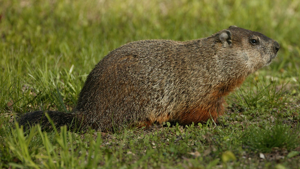

In [124]:
faq.display_image('woodchuck.jpg', width=300)

In [125]:
faq.clear_tar()